#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 8:Model Validation I: (ARIMA/SARIMA)
---
Topics

*  1. Model Summary
*  2. ARIMA Assumptions and Residual Diagonstics
*  3. SARIMA Assumptions and Residual Diagnostics
*  4. Comparing Residual Analysis of ARIMA and SARIMA Models
*  5. Comparing and evaluating overall fits
*  6. Discussion of Future Improvements

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Forecasting_Cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [ ]:
diff_series = df['Close'].diff().dropna()


In [ ]:
train = df[:-12]
test = df[-12:]

# 1. Model Summary

Let us begin by summarizing the models developed in Day 1.


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['Close'], order=(0,1,0))
fit = model.fit()

print(fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-THU will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  562
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1718.939
Date:                Sun, 29 Mar 2026   AIC                           3439.877
Time:                        15:06:54   BIC                           3444.207
Sample:                    01-01-2015   HQIC                          3441.568
                         - 10-02-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        26.8494      0.992     27.059      0.000      24.905      28.794
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               285.85
Prob(Q):                              0.87   Pr

In [ ]:
print(fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  562
Model:                 ARIMA(0, 1, 0)   Log Likelihood               -1718.939
Date:                Sun, 29 Mar 2026   AIC                           3439.877
Time:                        15:06:54   BIC                           3444.207
Sample:                    01-01-2015   HQIC                          3441.568
                         - 10-02-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2        26.8494      0.992     27.059      0.000      24.905      28.794
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               285.85
Prob(Q):                              0.87   Pr

ARIMA(0,1,0): captures trend via differencing

In [ ]:
!pip install pmdarima
import pmdarima as pm

# Fit auto_arima on training data with seasonal components
seasonal_auto_model = pm.auto_arima(
    train['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,            # let auto_arima determine the differencing
    seasonal=True,     # Enable seasonality
    m=52,              # Set seasonal period to 52 for weekly data
    stepwise=True,     # faster stepwise search
    trace=True         # shows progress
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 10.5 MB/s eta 0:00:00
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[52] intercept   : AIC=3442.932, Time=3.16 sec
 ARIMA(0,1,0)(0,0,0)[52] intercept   : AIC=3438.933, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[52] intercept   : AIC=3442.903, Time=3.03 sec
 ARIMA(0,1,1)(0,0,1)[52] intercept   : AIC=3442.901, Time=5.65 sec
 ARIMA(0,1,0)(0,0,0)[52]             : AIC=3439.877, Time=0.08 sec
 ARIMA(0,1,0)(1,0,0)[52] intercept   : AIC=3440.928, Time=2.17 sec
 ARIMA(0,1,0)(0,0,1)[52] intercept   : AIC=3440.928, Time=2.44 sec
 ARIMA(1,1,0)(0,0,0)[52] intercept   : AIC=3440.908, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[52] intercept   : AIC=3440.905, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[52] intercept   : AIC=3441.818, Time=0.52 sec

Best model:  ARIMA(0,1,0)(0,0,0)[52] intercept
Total fit time: 17.442 seconds


Seasonal ARIMA: extends ARIMA with seasonal structure


## Fitting a model is easy — validating it is the real work.
----

# 2. ARIMA Assumptions and Residual Diagonstics


We define residuals as

## $ r = y - \widehat{y} $

which is: residual = actual - predicted


After fitting an our model, we verify that the residuals satisfy key assumptions.

A valid model should leave residuals that behave like white noise.

## ARIMA Residuals

In [ ]:
residuals = fit.resid

## Assumption 1: **Zero Mean (Unbiased Errors)**

What it checks:

Residuals should be centered around zero

Model is not systematically over/under predicting

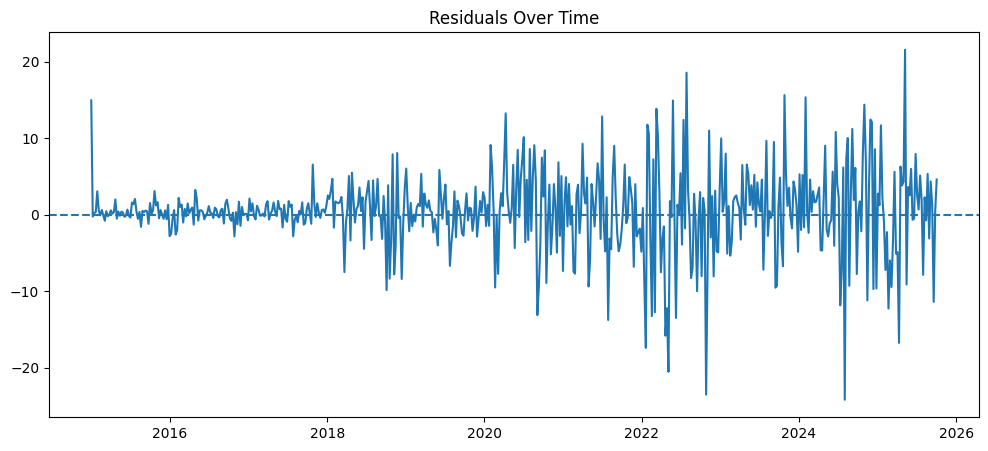

Mean of residuals: 0.4007473309608534


In [ ]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.axhline(0, linestyle='--')
plt.title("Residuals Over Time")
plt.show()

print("Mean of residuals:", residuals.mean())

Interpretation:

Mean ≈ 0 → good

Persistent deviation → bias in model

## Assumption 2: **No Autocorrelation (Independence)**

What it checks:

Residuals should not depend on past residuals

Model has captured all temporal structure

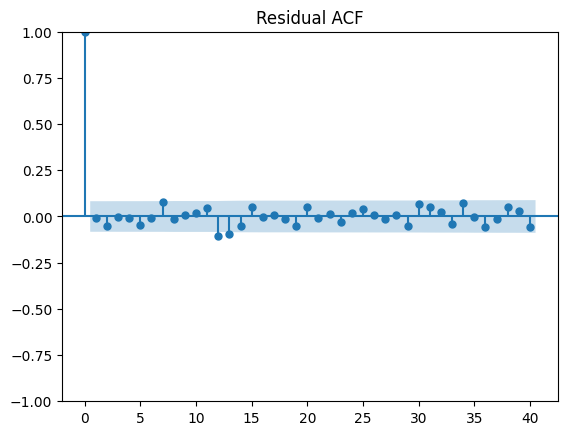

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals.dropna(), lags=40)
plt.title("Residual ACF")
plt.show()

Formal test for independence of residuals.

H₀: residuals are independent

H₁: residuals are autocorrelated

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals.dropna(), lags=[10], return_df=True)
print(lb_test)

     lb_stat  lb_pvalue
10  6.479733   0.773478


No spikes in ACF → good

Ljung-Box p > 0.05 → residuals are independent

Otherwise → model is incomplete

## Assumption 3: **Constant Variance (Homoskedasticity)**

What it checks:

Variability of residuals should be stable over time

No volatility clustering

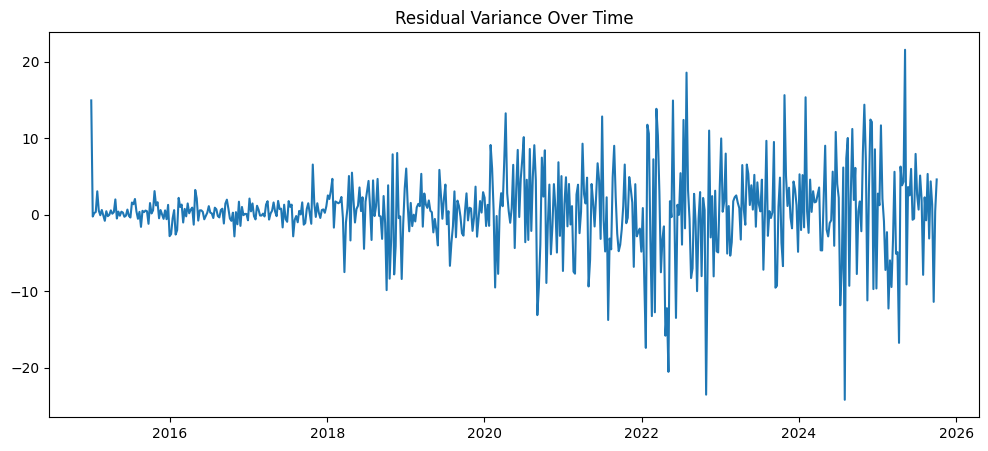

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(residuals)
plt.title("Residual Variance Over Time")
plt.show()

Even spread → good

Clusters of high/low variance → heteroskedasticity

## Assumption 4: **Normality of Residuals**

What it checks:

Residuals should follow an approximately normal distribution

Important for confidence intervals and inference

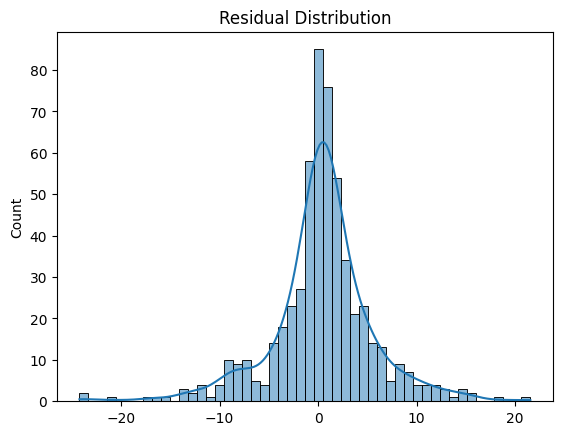

In [ ]:

import seaborn as sns

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

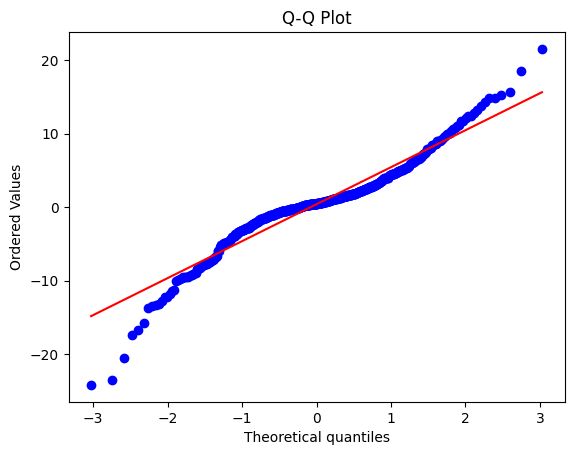

In [ ]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

Interpretation:

Bell-shaped histogram → good

Q-Q points follow line → good

Deviations → skewness or heavy tails

----

# 3. SARIMA Assumptions and Residual Diagnostics

## SARIMA Residuals

In [ ]:
residuals_seasonal = seasonal_auto_model.resid()

## Assumption 1: **Zero Mean (Unbiased Errors)**

What it checks:

Residuals should be centered around zero

Model is not systematically over/under predicting

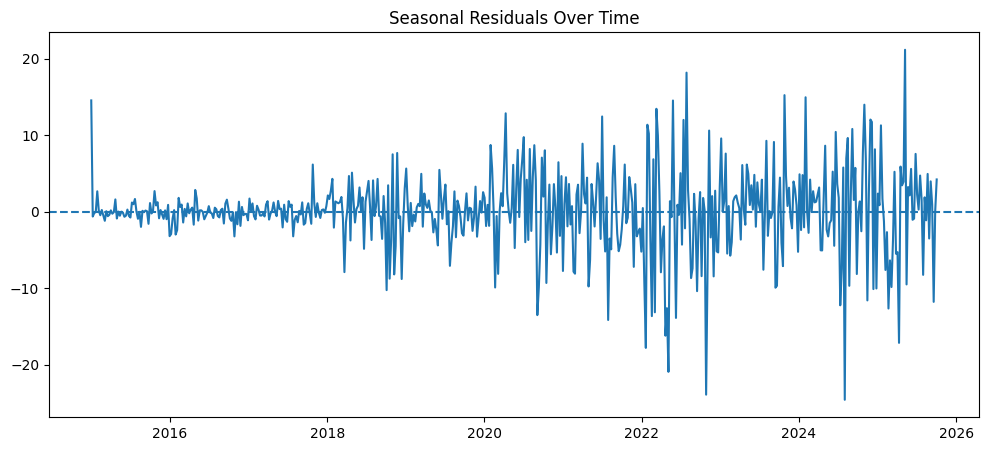

Mean of seasonal residuals: 0.02588280333162402


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(residuals_seasonal)
plt.axhline(0, linestyle='--')
plt.title("Seasonal Residuals Over Time")
plt.show()

print("Mean of seasonal residuals:", residuals_seasonal.mean())

Interpretation:

Mean ≈ 0 → good

Persistent deviation → bias in model

## Assumption 2: **No Autocorrelation (Independence)**

What it checks:

Residuals should not depend on past residuals

Model has captured all temporal structure

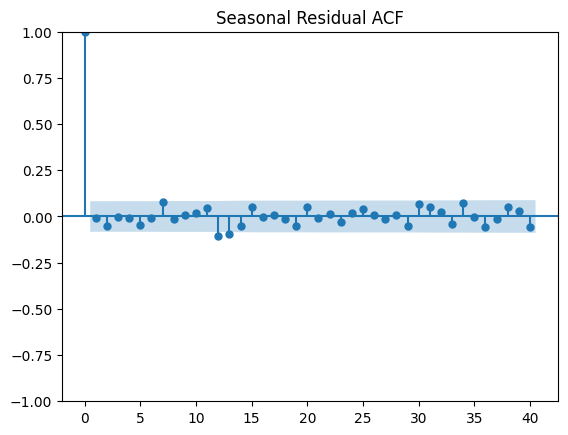

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals_seasonal.dropna(), lags=40)
plt.title("Seasonal Residual ACF")
plt.show()

Formal test for independence of residuals.

H₀: residuals are independent

H₁: residuals are autocorrelated

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test_seasonal = acorr_ljungbox(residuals_seasonal.dropna(), lags=[10], return_df=True)
print(lb_test_seasonal)

     lb_stat  lb_pvalue
10  6.479733   0.773478


No spikes in ACF → good

Ljung-Box p > 0.05 → residuals are independent

Otherwise → model is incomplete

## Assumption 3: **Constant Variance (Homoskedasticity)**

What it checks:

Variability of residuals should be stable over time

No volatility clustering

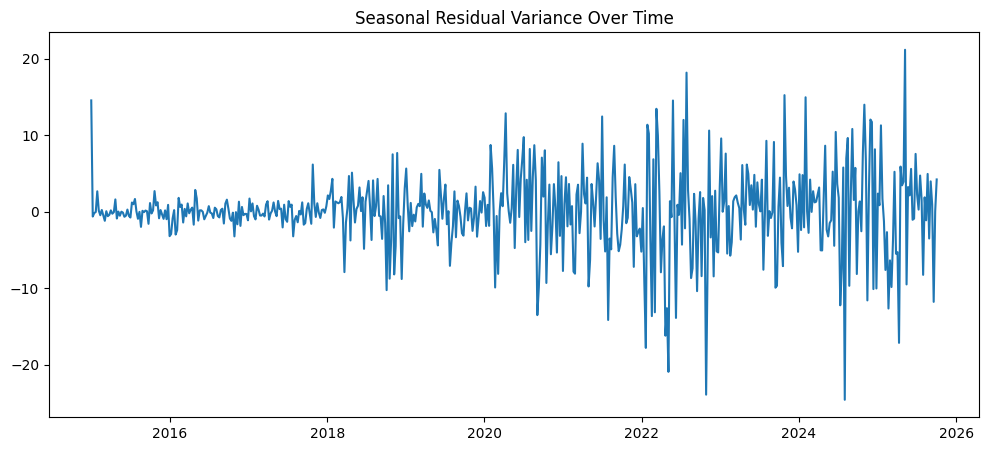

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(residuals_seasonal)
plt.title("Seasonal Residual Variance Over Time")
plt.show()

Even spread → good

Clusters of high/low variance → heteroskedasticity

## Assumption 4: **Normality of Residuals**

What it checks:

Residuals should follow an approximately normal distribution

Important for confidence intervals and inference

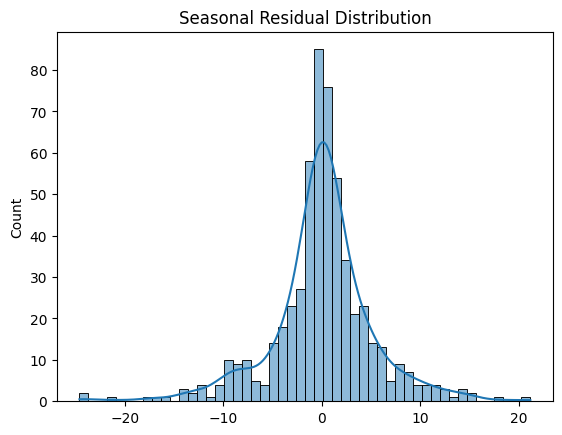

In [ ]:
import seaborn as sns

sns.histplot(residuals_seasonal, kde=True)
plt.title("Seasonal Residual Distribution")
plt.show()

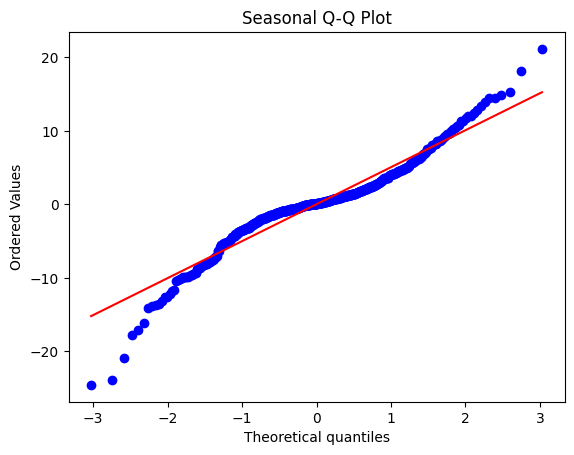

In [ ]:
import scipy.stats as stats

stats.probplot(residuals_seasonal, dist="norm", plot=plt)
plt.title("Seasonal Q-Q Plot")
plt.show()

Interpretation:

Bell-shaped histogram → good

Q-Q points follow line → good

Deviations → skewness or heavy tails

----

# 4. Comparing Residual Analysis of ARIMA and SARIMA Models


## Summarize ARIMA Residual Analysis

Based on the diagnostic tests for the ARIMA(0,1,0) model residuals (`fit.resid`):

### 1. Zero Mean (Unbiased Errors)
*   **Observation:** The mean of the residuals is `0.4007`, which is relatively close to zero.
*   **Interpretation:** This suggests that the ARIMA model is not systematically biased and does not consistently over- or under-predict the actual values. The assumption of zero mean residuals is reasonably satisfied.

### 2. No Autocorrelation (Independence)
*   **Observation:** The Ljung-Box test at lag 10 reports a p-value of `0.773`.
*   **Interpretation:** Since the p-value (`0.773`) is greater than the standard significance level of 0.05, we fail to reject the null hypothesis. This indicates that there is no significant autocorrelation in the residuals, meaning they behave like white noise. The assumption of independence is satisfied.

### 3. Constant Variance (Homoskedasticity)
*   **Observation:** The heteroskedasticity test (`Prob(H)`) from the model summary reports a p-value of `0.00`.
*   **Interpretation:** Because the p-value (`0.00`) is less than 0.05, we reject the null hypothesis of constant variance. This indicates that the residuals exhibit heteroskedasticity, meaning their variance changes over time. This is a concern and suggests the model may not fully capture volatility dynamics.

### 4. Normality of Residuals
*   **Observation:** The Jarque-Bera test (`Prob(JB)`) reports a p-value of `0.00`.
*   **Interpretation:** Since the p-value (`0.00`) is below 0.05, we reject the null hypothesis of normality. This indicates that the residuals are not normally distributed, likely showing skewness or heavy tails. This may impact the reliability of confidence intervals and statistical inference.

## Summarize SARIMA Residual Analysis

Based on the diagnostic tests for the SARIMA model residuals (`seasonal_auto_model.resid()`):

### 1. Zero Mean (Unbiased Errors)
*   **Observation:** The mean of the seasonal residuals is approximately `0.02588`, which is very close to zero.
*   **Interpretation:** This indicates that the SARIMA model's predictions are not systematically biased, meaning it does not consistently over- or under-predict the actual values. The assumption of zero mean residuals is met.

### 2. No Autocorrelation (Independence)
*   **Observation:** The Ljung-Box test for seasonal residuals (`lb_test_seasonal`) at lag 10 shows a p-value of `0.773478`.
*   **Interpretation:** Since the p-value (`0.773478`) is significantly greater than the common significance level of 0.05, we fail to reject the null hypothesis. This suggests that there is no significant autocorrelation present in the seasonal residuals. The model has adequately captured the temporal dependencies, and the residuals behave like white noise. The assumption of no autocorrelation is met.

### 3. Constant Variance (Homoskedasticity)
*   **Observation:** Visual inspection of the 'Seasonal Residual Variance Over Time' plot (cell `419e0f46`) reveals fluctuations in the spread of residuals, with some periods showing higher variability than others. Financial time series data often exhibits periods of high and low volatility.
*   **Interpretation:** This suggests the presence of heteroskedasticity (non-constant variance) in the residuals, which is common in financial data. The assumption of homoskedasticity is likely violated. While the model captures the mean well, it might not fully account for changes in volatility over time.

### 4. Normality of Residuals
*   **Observation:** The 'Seasonal Residual Distribution' histogram appears somewhat bell-shaped, but the 'Seasonal Q-Q Plot' shows deviations from the straight line, particularly at the tails.
*   **Interpretation:** This indicates that the residuals are not perfectly normally distributed. The deviations in the Q-Q plot suggest that the residuals may have heavier tails than a normal distribution, implying that extreme errors occur more frequently than predicted by a normal distribution. The assumption of normality is likely violated, which could impact the reliability of confidence intervals and hypothesis tests.


# 5. Comparing and evaluating overall fits

In [ ]:
#Getting predictions from ARIMA and SARIMA models for the same length as your test set
forecast = fit.forecast(steps=len(test))
seasonal_forecast = seasonal_auto_model.predict(n_periods=len(test))

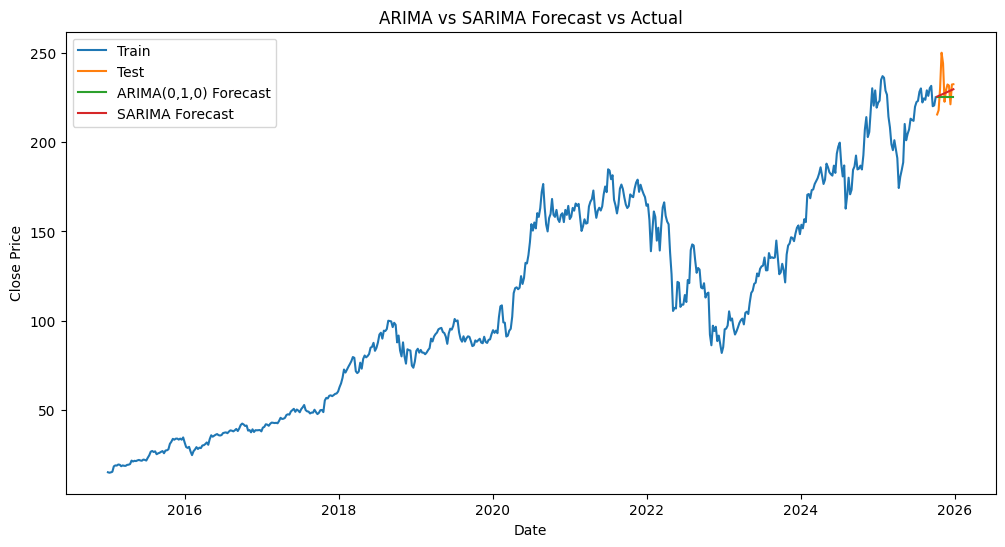

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Test')
plt.plot(test.index, forecast, label='ARIMA(0,1,0) Forecast') # Previous flat forecast
plt.plot(test.index, seasonal_forecast, label='SARIMA Forecast') # New seasonal forecast

plt.legend()
plt.title("ARIMA vs SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()



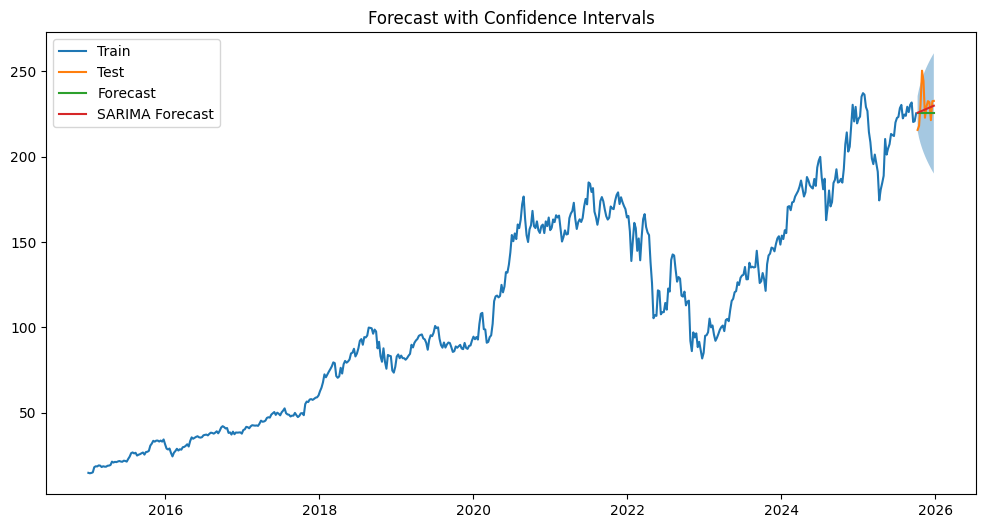

In [ ]:
forecast_obj = fit.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05) #1-alpha % CI

plt.figure(figsize=(12,6))

plt.plot(train.index, train['Close'], label='Train')
plt.plot(test.index, test['Close'], label='Test')
plt.plot(test.index, forecast_mean, label='Forecast')
plt.plot(test.index, seasonal_forecast, label='SARIMA Forecast') # New seasonal forecast


plt.fill_between(
    test.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    alpha=0.4 #shade level
)

plt.legend()
plt.title("Forecast with Confidence Intervals")
plt.show()

 - The shaded area around the forecast (from conf_int) represents the confidence interval for the predicted values. It shows the range where the model expects the true future values to fall.

 - The width of the CI grows as you move further into the forecast horizon, reflecting increasing uncertainty for long-term predictions.

 - Most of the test data falls within the confidence interval, suggesting that the models forecast is reasonably reliable, though extreme deviations may still occur.

**Mean Absolute Error (MAE):**

$$
\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \lvert y_i - \hat{y}_i \rvert
\quad \text{where: }
y_i \text{ is the actual value, }
\hat{y}_i \text{ is the predicted value, and }
n \text{ is the number of observations.}
$$

**Mean Squared Error (MSE):**

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\quad \text{where: }
y_i \text{ is the actual value, }
\hat{y}_i \text{ is the predicted value, and }
n \text{ is the number of observations.}
$$

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

In [ ]:
#ARIMA metrics
rmse = np.sqrt(mean_squared_error(test['Close'], forecast))
mae = mean_absolute_error(test['Close'], forecast)

print(" ARIMA RMSE:", rmse)
print(" ARIMA RMSE:", mae)

 ARIMA RMSE: 10.772459097160683
 ARIMA RMSE: 8.714166666666666


In [ ]:
#SARIMA metrics
rmse_seasonal = np.sqrt(mean_squared_error(test['Close'], seasonal_forecast))
mae__seasonal = mean_absolute_error(test['Close'], seasonal_forecast)

print("Seasonal ARIMA RMSE:", rmse_seasonal)
print("Seasonal ARIMA RMSE:", mae__seasonal)

Seasonal ARIMA RMSE: 9.801500141211665
Seasonal ARIMA RMSE: 7.464618241235907



# 6. Discussion of Future Improvements

Based on the observed residual diagnostics, the following improvements could be considered for both models:

*   **Address Heteroskedasticity:**
    *   **ARCH/GARCH Models:** Integrate GARCH (Generalized Autoregressive Conditional Heteroskedasticity) components into the ARIMA or SARIMA framework. ARIMA-GARCH or SARIMA-GARCH models are specifically designed to capture and model the changing variance (volatility clustering) often seen in financial data.
    *   **Data Transformation:** Apply a variance-stabilizing transformation, such as a logarithmic transformation, to the original time series. However, this changes the interpretation of the forecasts back to the original scale.
*   **Address Non-Normality:**
    *   **Robust Models:** Explore models that are more robust to non-normal error distributions or assume alternative error distributions (e.g., Student's t-distribution).
    *   **Outlier Detection and Treatment:** Investigate and potentially address significant outliers in the original data or residuals, as they can heavily influence normality assumptions and create heavy tails.
    *   **Alternative Forecasting Methods:** Consider models beyond traditional ARIMA/SARIMA if these assumptions remain violated and impact forecast accuracy or confidence interval reliability. For instance, state-space models or machine learning approaches might offer different ways to handle these complexities.
